# Import Thư viện

In [320]:
import pandas as pd
import matplotlib.pyplot  as plt
import numpy              as np
import plotly.express       as px
import pydotplus         as pdp
import seaborn as sns
from scipy import stats
from sklearn import tree
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics          import mean_absolute_error, mean_squared_error
from IPython.display         import Image
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics          import accuracy_score, confusion_matrix
from sklearn.metrics          import auc,roc_curve
from sklearn.metrics          import precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import PowerTransformer
from scipy.stats.mstats import winsorize

# Import Data

In [321]:
df3 = pd.read_csv('./data/paris_weekdays.csv')
df4 = pd.read_csv('./data/paris_weekends.csv')

df3['weekends'] = 0
df4['weekends'] = 1

d = [df3, df4]
df = pd.concat(d, axis= 0)
df = df.rename(columns= {df.columns[0]: 'ID'})
df.drop(['ID', 'attr_index_norm', 'rest_index_norm'], axis=1, inplace=True)
df

,realSum,room_type,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,rest_index,lng,lat,weekends
0,296.159940,Private room,False,True,2.0,True,0,0,10.0,97.0,1,0.699821,0.193709,518.478947,1218.662228,2.35385,48.86282,0
1,288.237487,Private room,False,True,2.0,True,0,0,10.0,97.0,1,2.100005,0.107221,873.216962,1000.543327,2.32436,48.85902,0
2,211.343089,Private room,False,True,2.0,False,0,0,10.0,94.0,1,3.302325,0.234724,444.556077,902.854467,2.31714,48.87475,0
3,298.956100,Entire home/apt,False,False,2.0,False,0,1,9.0,91.0,1,0.547567,0.195997,542.142014,1199.184166,2.35600,48.86100,0
4,247.926181,Entire home/apt,False,False,4.0,False,0,0,7.0,82.0,1,1.197921,0.103573,406.928958,1070.775497,2.35915,48.86648,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3553,295.460900,Entire home/apt,False,False,4.0,False,0,0,9.0,80.0,1,3.660389,0.168146,209.752453,540.326583,2.38051,48.88393,1
3554,232.081275,Entire home/apt,False,False,4.0,False,0,0,10.0,98.0,1,3.558813,0.154703,185.486701,474.351813,2.40050,48.85093,1
3555,223.925809,Entire home/apt,False,False,2.0,False,1,0,9.0,89.0,1,4.205205,0.253029,172.658919,406.585935,2.40100,48.87700,1
3556,200.857489,Entire home/apt,False,False,2.0,True,0,0,9.0,93.0,1,2.891214,0.240674,235.167925,602.451672,2.38200,48.87400,1


# Tổng quan bộ dữ liệu

# Chuẩn bị dữ liệu

In [322]:
continuous_cols = ['realSum', 'guest_satisfaction_overall', 
                 'dist','metro_dist', 'attr_index','rest_index', 'lng', 'lat']
discrete_cols = ['person_capacity', 'cleanliness_rating', 'bedrooms' ]
binary_cols = ['room_shared', 'room_private', 'host_is_superhost', 'multi', 'biz', 'weekends']
nominal_cols = ['room_type']
bool_cols = ['room_shared', 'room_private', 'host_is_superhost']

num_cols = continuous_cols + discrete_cols

# Tiền xử lý

### Chung cho cả Classification và Regression

In [323]:
df['x'] = np.cos(np.radians(df['lat'])) * np.cos(np.radians(df['lng']))
df['y'] = np.cos(np.radians(df['lat'])) * np.sin(np.radians(df['lng']))
df['z'] = np.sin(np.radians(df['lat']))

df = df.drop(['lng', 'lat'], axis= 1)

In [324]:
encoder_1 = LabelEncoder()
df['room_type'] =  encoder_1.fit_transform(df['room_type'])

df[bool_cols] = df[bool_cols].astype(int)

In [325]:
df.corr()['realSum'].sort_values(ascending=False)

realSum                       1.000000
person_capacity               0.395620
bedrooms                      0.353561
attr_index                    0.252642
rest_index                    0.212614
biz                           0.104630
cleanliness_rating            0.068471
guest_satisfaction_overall    0.058530
x                             0.045607
host_is_superhost             0.022569
multi                         0.018087
weekends                     -0.017729
metro_dist                   -0.026076
z                            -0.036172
room_shared                  -0.086654
dist                         -0.099366
y                            -0.139742
room_private                 -0.153378
room_type                    -0.181257
Name: realSum, dtype: float64

In [326]:
df_clf = df.copy()
df_reg = df.copy()

df.shape

(6688, 19)

### Utility

In [327]:
def auto_transform_skewed(df, numeric_cols, skew_threshold=0.5):
    """
    Tự động phát hiện và xử lý lệch (skewness) trong các cột numeric.
    Áp dụng:
      - Box-Cox nếu skew > threshold và toàn bộ > 0
      - Yeo-Johnson nếu skew > threshold và có giá trị <= 0
      - Power transform (phản chiếu) nếu skew < -threshold
    """
    transform_summary = {}

    for col in numeric_cols:
        skew = df_reg[col].skew()
        method = None

        if abs(skew) < skew_threshold:
            continue

        # right skew
        if skew > skew_threshold:
            if (df[col] > 0).all():
                df_reg[col], _ = stats.boxcox(df[col])
                method = 'Box-Cox'
            else:
                pt = PowerTransformer(method='yeo-johnson')
                df_reg[col] = pt.fit_transform(df[[col]])
                method = 'Yeo-Johnson'
            print(f"{col}: skew={skew:.2f}: right skew → dùng {method}")

        # left skew
        elif skew < -skew_threshold:
            # Power transform ngược lại (flip sign rồi transform)
            flipped = -df[col] + df[col].max() + 1
            pt = PowerTransformer(method='yeo-johnson')
            df_reg[col] = -pt.fit_transform(flipped.to_frame())
            method = 'Power transform (left skew)'
            print(f"{col}: skew={skew:.2f}: left skew → dùng {method}")

        transform_summary[col] = {'skew_before': skew, 'method': method}

    return df_reg, pd.DataFrame(transform_summary).T

def count_extreme_outliers(df, cols):
    extreme_counts = {}
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 3*IQR
        upper = Q3 + 3*IQR
        count = ((df[col] < lower) | (df[col] > upper)).sum()
        extreme_counts[col] = count
    return extreme_counts

def regression_eval(y_test, y_pred):
    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    return mae, mse

### Cho Classification

In [328]:
# Tính trung vị của giá
median_price = df_clf['realSum'].median()

# Hàm phân loại 2 nhóm giá
def classify_price(x):
    if x <= median_price:
        return 'Thấp'
    else:
        return 'Cao'

In [329]:
# Tạo cột nhãn
df_clf['price_group'] = df_clf['realSum'].apply(classify_price)

encoder = OrdinalEncoder()
df_clf[['room_type']] = encoder.fit_transform(df_clf[['room_type']])

In [330]:
# Tạo tập dữ liệu
# -----------------------------
X = df_clf.drop(['realSum', 'price_group'], axis=1)
y = df_clf['price_group']

# Chia train/test (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [331]:
# Tiền xử lý biến lệch phải (log-transform)
# -----------------------------
cols_skewed = ['dist', 'metro_dist', 'attr_index', 'rest_index']
for col in cols_skewed:
    if col in X_train.columns:
        X_train[col] = np.log1p(X_train[col])
        X_test[col] = np.log1p(X_test[col])

### Cho Regression

<Axes: ylabel='guest_satisfaction_overall'>

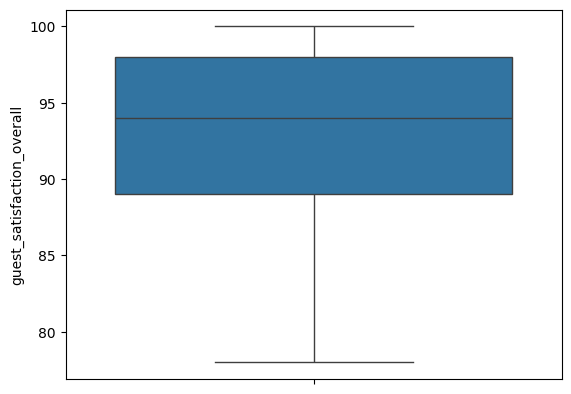

In [332]:
cols_to_winsorize_right = ['realSum', 'attr_index', 'metro_dist']
cols_to_winsorize_left = ['guest_satisfaction_overall']

for col in cols_to_winsorize_right:
    df_reg[col] = winsorize(df_reg[col], limits=[0, 0.05]).data

for col in cols_to_winsorize_left:
    df_reg[col] = winsorize(df_reg[col], limits=[0.05, 0]).data

sns.boxplot(df_reg['guest_satisfaction_overall'])

In [333]:
numeric_cols = df_reg.select_dtypes(include = ['float64', 'int64'])
df_reg, summary = auto_transform_skewed(df_reg, numeric_cols)

realSum: skew=1.05: right skew → dùng Box-Cox
room_type: skew=1.52: right skew → dùng Yeo-Johnson
room_shared: skew=8.26: right skew → dùng Yeo-Johnson
room_private: skew=1.29: right skew → dùng Yeo-Johnson
person_capacity: skew=0.99: right skew → dùng Box-Cox
host_is_superhost: skew=2.07: right skew → dùng Yeo-Johnson
multi: skew=1.36: right skew → dùng Yeo-Johnson
biz: skew=1.18: right skew → dùng Yeo-Johnson
cleanliness_rating: skew=-2.25: left skew → dùng Power transform (left skew)
guest_satisfaction_overall: skew=-0.75: left skew → dùng Power transform (left skew)
bedrooms: skew=0.67: right skew → dùng Yeo-Johnson
attr_index: skew=0.65: right skew → dùng Box-Cox


In [334]:
# Giả sử các cột numeric sau Box-Cox/Yeo-Johnson
numeric_cols = ['metro_dist', 'attr_index', 'rest_index', 'realSum', 'guest_satisfaction_overall']
extreme_counts = count_extreme_outliers(df_reg, numeric_cols)
extreme_counts

{'metro_dist': np.int64(0),
 'attr_index': np.int64(0),
 'rest_index': np.int64(0),
 'realSum': np.int64(0),
 'guest_satisfaction_overall': np.int64(0)}

# Build Model

### Regression

In [335]:
X_reg = df_reg.drop('realSum', axis=1, inplace=False)
y_reg = df_reg['realSum']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=81)

In [336]:
reg = DecisionTreeRegressor(criterion='squared_error', max_depth= 5)
reg_model = reg.fit(X_train_reg, y_train_reg)

In [337]:
y_pred_reg = reg_model.predict(X_test_reg)
errors   = regression_eval(y_test_reg, y_pred_reg)
r2_total_reg = reg_model.score(X_reg, y_reg)
r2_train_reg = reg_model.score(pd.DataFrame(X_train_reg), y_train_reg)
r2_test_reg  = reg_model.score(pd.DataFrame(X_test_reg),  y_test_reg)

## Hiển thị giá trị các chỉ số
print(f'MAE = {errors[0]:.1f}%')
print(f'MSE = {errors[1]:.1f}%')
print(f'Mô hình giải thích được {(r2_total_reg * 100):.1f}% toàn bộ dữ liệu')
print(f'Mô hình giải thích được {(r2_train_reg * 100):.1f}% training set')
print(f'Mô hình  giải thích được {(r2_test_reg  * 100):.1f}% test set')

MAE = 0.1%
MSE = 0.0%
Mô hình giải thích được 55.7% toàn bộ dữ liệu
Mô hình giải thích được 56.3% training set
Mô hình  giải thích được 53.1% test set


In [338]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error

params = []
acc = []

model = DecisionTreeRegressor()

param_grid = {
    'criterion': ['squared_error'],
    'splitter': ['best'],
    'max_depth': [30, 35, 40, 45],
    'min_samples_split': [8, 10, 12, 14],
    'min_samples_leaf': [2, 4, 6, 8],
    'max_features': [None],
    'max_leaf_nodes': [150],
    'ccp_alpha': [0.0]
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_reg, y_train_reg)

params.append(grid_search.best_params_)

best_model_reg = grid_search.best_estimator_
y_pred_test_reg = best_model_reg.predict(X_test_reg)
y_pred_train_reg = best_model_reg.predict(X_train_reg)

test_r2_reg = r2_score(y_test_reg, y_pred_test_reg)
train_r2_reg = r2_score(y_train_reg, y_pred_train_reg)

train_mse_reg = mean_squared_error(y_train_reg, y_pred_train_reg)
test_mse_reg  = mean_squared_error(y_test_reg, y_pred_test_reg)

acc.append({
    'train_r2': train_r2_reg,
    'test_r2': test_r2_reg,
    'train_mse': train_mse_reg,
    'test_mse': test_mse_reg
})

params_df = pd.DataFrame(params)
acc_df = pd.DataFrame(acc)


Fitting 5 folds for each of 64 candidates, totalling 320 fits


In [339]:
r = [params_df, acc_df]
result_df = pd.concat(r, axis= 1)
result_df['test_train_diff'] = result_df['train_r2'] - result_df['test_r2']
result_df

,ccp_alpha,criterion,max_depth,max_features,max_leaf_nodes,min_samples_leaf,min_samples_split,splitter,train_r2,test_r2,train_mse,test_mse,test_train_diff
0,0.0,squared_error,30,None,150,4,8,best,0.717008,0.634459,0.012859,0.016989,0.082549


### Classification

In [340]:
# Tìm tham số tốt nhất cho CART
# -----------------------------
param_grid = {
    'max_depth': [4, 6, 8, 10, None],
    'min_samples_leaf': [5, 10, 20, 30],
    'criterion': ['gini'],
    'class_weight': [None, 'balanced']
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Cross-validation accuracy:", round(grid_search.best_score_, 3))

Best parameters: {'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 5}
Cross-validation accuracy: 0.787


In [341]:
# Huấn luyện CART với tham số tối ưu
# -----------------------------
best_clf = grid_search.best_estimator_
best_clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [342]:
# Đánh giá mô hình
# -----------------------------
y_train_pred = best_clf.predict(X_train)
y_test_pred = best_clf.predict(X_test)

# HIỆU SUẤT TRÊN TẬP HUẤN LUYỆN
# =============================
print("===== HIỆU SUẤT TRÊN TẬP HUẤN LUYỆN =====")
print("Accuracy (Train):", round(accuracy_score(y_train, y_train_pred), 3))
print("\nClassification Report (Train):\n", classification_report(y_train, y_train_pred))
print("Confusion Matrix (Train):\n", confusion_matrix(y_train, y_train_pred))

# =============================
# HIỆU SUẤT TRÊN TẬP KIỂM TRA
# =============================
print("\n===== HIỆU SUẤT TRÊN TẬP KIỂM TRA =====")
print("Accuracy (Test):", round(accuracy_score(y_test, y_test_pred), 3))
print("\nClassification Report (Test):\n", classification_report(y_test, y_test_pred))
print("Confusion Matrix (Test):\n", confusion_matrix(y_test, y_test_pred))

===== HIỆU SUẤT TRÊN TẬP HUẤN LUYỆN =====
Accuracy (Train): 0.915

Classification Report (Train):
               precision    recall  f1-score   support

         Cao       0.90      0.93      0.92      2338
        Thấp       0.93      0.90      0.91      2343

    accuracy                           0.92      4681
   macro avg       0.92      0.92      0.92      4681
weighted avg       0.92      0.92      0.92      4681

Confusion Matrix (Train):
 [[2171  167]
 [ 230 2113]]

===== HIỆU SUẤT TRÊN TẬP KIỂM TRA =====
Accuracy (Test): 0.791

Classification Report (Test):
               precision    recall  f1-score   support

         Cao       0.78      0.81      0.79      1002
        Thấp       0.80      0.78      0.79      1005

    accuracy                           0.79      2007
   macro avg       0.79      0.79      0.79      2007
weighted avg       0.79      0.79      0.79      2007

Confusion Matrix (Test):
 [[808 194]
 [225 780]]


In [343]:
# Lấy giá trị alpha có thể tỉa
path = best_clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[:-1]  # bỏ alpha cuối vì sẽ tỉa toàn bộ cây

train_scores = []
test_scores = []

for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(
        random_state=42,
        criterion=grid_search.best_params_['criterion'],
        class_weight=grid_search.best_params_['class_weight'],
        max_depth=grid_search.best_params_['max_depth'],
        min_samples_leaf=grid_search.best_params_['min_samples_leaf'],
        ccp_alpha=alpha
    )
    clf.fit(X_train, y_train)
    train_scores.append(clf.score(X_train, y_train))
    test_scores.append(clf.score(X_test, y_test))


In [344]:
# Chọn alpha tốt nhất (max test accuracy)
best_alpha = ccp_alphas[np.argmax(test_scores)]
print("Best ccp_alpha:", round(best_alpha, 5))

Best ccp_alpha: 0.00069


In [345]:
# Huấn luyện lại mô hình với alpha tối ưu
pruned_clf = DecisionTreeClassifier(
    random_state=42,
    criterion=grid_search.best_params_['criterion'],
    class_weight=grid_search.best_params_['class_weight'],
    max_depth=grid_search.best_params_['max_depth'],
    min_samples_leaf=grid_search.best_params_['min_samples_leaf'],
    ccp_alpha=best_alpha
)
pruned_clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [346]:
# Đánh giá lại
y_train_pred_pruned = pruned_clf.predict(X_train)
y_test_pred_pruned = pruned_clf.predict(X_test)

# HIỆU SUẤT TRÊN TẬP HUẤN LUYỆN
# =============================
print("===== HIỆU SUẤT TRÊN TẬP HUẤN LUYỆN (PRUNED TREE) =====")
print("Train Accuracy:", round(accuracy_score(y_train, y_train_pred_pruned), 3))
print("\nClassification Report (Train):\n", classification_report(y_train, y_train_pred_pruned))
print("Confusion Matrix (Train):\n", confusion_matrix(y_train, y_train_pred_pruned))

# =============================
# HIỆU SUẤT TRÊN TẬP KIỂM TRA
# =============================
print("\n===== HIỆU SUẤT TRÊN TẬP KIỂM TRA (PRUNED TREE) =====")
print("Test Accuracy:", round(accuracy_score(y_test, y_test_pred_pruned), 3))
print("\nClassification Report (Test):\n", classification_report(y_test, y_test_pred_pruned))
print("Confusion Matrix (Test):\n", confusion_matrix(y_test, y_test_pred_pruned))

===== HIỆU SUẤT TRÊN TẬP HUẤN LUYỆN (PRUNED TREE) =====
Train Accuracy: 0.878

Classification Report (Train):
               precision    recall  f1-score   support

         Cao       0.87      0.88      0.88      2338
        Thấp       0.88      0.87      0.88      2343

    accuracy                           0.88      4681
   macro avg       0.88      0.88      0.88      4681
weighted avg       0.88      0.88      0.88      4681

Confusion Matrix (Train):
 [[2068  270]
 [ 300 2043]]

===== HIỆU SUẤT TRÊN TẬP KIỂM TRA (PRUNED TREE) =====
Test Accuracy: 0.813

Classification Report (Test):
               precision    recall  f1-score   support

         Cao       0.81      0.81      0.81      1002
        Thấp       0.81      0.81      0.81      1005

    accuracy                           0.81      2007
   macro avg       0.81      0.81      0.81      2007
weighted avg       0.81      0.81      0.81      2007

Confusion Matrix (Test):
 [[815 187]
 [189 816]]
